# Variational Quantum Simulation of the Multi-Flavor Schwinger Model
### Single self-contained notebook — run top to bottom to regenerate every table and figure

Convention: `nu0only` (matches Melzer *et al.* 2025; N=3 phase boundary at |K| ~ 5.6).
Both Hamiltonian bug-fixes (kinetic doubling, staggered-charge background) are baked in.

**How to run:** Runtime menu -> Run all. Set `FAST = True` in the config cell for a
~2-minute smoke run (fewer VQE restarts); `FAST = False` reproduces the paper figures
(~15-30 min, the VQE-based figures 2-6 dominate). Figures are shown inline and saved to `final_figs/`.

In [9]:
import os, time, warnings, math
import numpy as np
from math import comb
from itertools import combinations
from scipy.linalg import eigh
from scipy.optimize import minimize
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

# ---- run-quality switch -----------------------------------------------------
FAST = False     # True  -> quick smoke run (fewer restarts, ~2 min)
                 # False -> paper-quality (more restarts, ~15-30 min)
R = (dict(ksweep=2, penalty=3, stability=4, scaling=2, conv=2, maxiter=800)
     if FAST else
     dict(ksweep=8, penalty=10, stability=20, scaling=6, conv=5, maxiter=2500))

X = 16.0                       # coupling, fixed throughout
os.makedirs("final_figs", exist_ok=True)
plt.rcParams.update({"font.family": "serif", "font.size": 9, "figure.dpi": 120,
                     "savefig.bbox": "tight", "savefig.dpi": 150})
print("FAST =", FAST, "| restart budget:", R)

FAST = False | restart budget: {'ksweep': 8, 'penalty': 10, 'stability': 20, 'scaling': 6, 'conv': 5, 'maxiter': 2500}


## 1. Core code (validated)
Hamiltonian, ansatze, observables, VQE, noise/ZNE, and shot-noise. This is the same
code as the `schwinger_vqe` package; the benchmark cell below checks it against the
manuscript numbers.

In [10]:
# ===== hamiltonian.py =====
"""
Kogut-Susskind -> Jordan-Wigner spin Hamiltonian for the two-flavor Schwinger
model, in the Q_tot = 0 physical sector.

Two chemical-potential conventions are supported:

    'nu0only'  (DEFAULT, the manuscript convention)
        nu_0 = 2 sqrt(x) K   on flavor 0,   nu_1 = 0.
        Reproduces the trapped-ion benchmark of Melzer et al. (2025):
            E0(N=2) = -223.0, -30.5644, +1.0  at K = -14, 0, +10.
        N=3 first-order phase boundary at |K| ~ 5.6.

    'antisym'  (isospin chemical potential, NOT used in the paper)
        nu_0 = +2 sqrt(x) K,  nu_1 = -2 sqrt(x) K.
        N=3 boundary at |K| ~ 2.8.  Provided only for comparison.

Two well-understood bugs are fixed here and must stay fixed:

  (1) Kinetic doubling.  The hop must iterate over |01> states only
      (b1 == 0 and b2 == 1) and set H[i,j] and H[j,i] together.  Using the
      condition b1 != b2 double-counts every hop and doubles the kinetic energy.

  (2) Staggered charge background.  The Kogut-Susskind charge is
          Q_n = sum_f occ_{n,f} - (F/2)(1 - (-1)^n).
      Dropping the background term -(F/2)(1-(-1)^n) lowers the K=0 energies by
      ~1-2 units relative to Table I.

Qubit ordering note: build_H_full / build_H_subspace use the convention that
qubit p = n*F + f occupies bit (nq-1-p) of the integer state label (MSB-first,
matching the gate primitives in ansatz.py).  build_hamiltonian (the basis-indexed
builder used by the noise module) uses LSB-first labelling; the two never share
state integers, so this is internal-only.
"""



CONVENTION_DEFAULT = "nu0only"

# --- Pauli matrices / tensor infrastructure (MSB-first qubit ordering) -------

_I2 = np.eye(2, dtype=complex)
_X2 = np.array([[0, 1], [1, 0]], dtype=complex)
_Y2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
_Z2 = np.array([[1, 0], [0, -1]], dtype=complex)


def kron_list(ops):
    r = ops[0]
    for op in ops[1:]:
        r = np.kron(r, op)
    return r


def _single_Z(q, nq):
    ops = [_I2] * nq
    ops[q] = _Z2
    return kron_list(ops)


def sector_dim(N):
    """Dimension of the Q_tot = 0 sector, C(2N, N)."""
    return comb(2 * N, N)


def nu_of(K, x, convention=CONVENTION_DEFAULT):
    """Return (nu_0, nu_1) for a given convention."""
    a = 2.0 * np.sqrt(x) * K
    if convention == "nu0only":
        return a, 0.0
    if convention == "antisym":
        return a, -a
    raise ValueError("convention must be 'nu0only' or 'antisym'")


# --- Full-space (2^{2N} x 2^{2N}) operator-form Hamiltonian ------------------

def build_H_full(x, K, N=2, F=2, convention=CONVENTION_DEFAULT):
    """
    Dense Hamiltonian on the full 2^{2N} Hilbert space (operator form).

    Used for the gauge-invariant vs hardware-efficient comparison, where the
    unconstrained ansatz must be able to leave the physical sector.
    """
    nu0, nu1 = nu_of(K, x, convention)
    nu = [nu0, nu1]
    nq = N * F
    dim = 2 ** nq
    H = np.zeros((dim, dim), dtype=complex)
    Imat = np.eye(dim, dtype=complex)

    # kinetic hop
    for n in range(N - 1):
        for f in range(F):
            p1, p2 = n * F + f, (n + 1) * F + f
            z_str = list(range(p1 + 1, p2))
            for G in (_X2, _Y2):
                ops = [_I2] * nq
                ops[p1] = G
                ops[p2] = G
                for qz in z_str:
                    ops[qz] = _Z2
                H += -x / 2 * kron_list(ops)

    # chemical potential
    for n in range(N):
        for f in range(F):
            q = n * F + f
            H += nu[f] / 2 * (_single_Z(q, nq) + Imat)

    # electric field: sum_{ne} (sum_{k<=ne} Q_k)^2, with charge background
    for ne in range(N - 1):
        cumQ = np.zeros((dim, dim), dtype=complex)
        for k in range(ne + 1):
            for f in range(F):
                q = k * F + f
                cumQ += (Imat - _single_Z(q, nq)) / 2
            cumQ -= F / 2.0 * (1 - (-1) ** k) * Imat
        H += cumQ @ cumQ
    return H


# --- Physical-sector (C(2N,N) x C(2N,N)) Hamiltonian, fast ------------------

def physical_basis(N, F=2):
    """Integer labels of the Q_tot=0 sector (MSB-first), and a reverse index."""
    nq = N * F
    basis = [s for s in range(2 ** nq)
             if sum(1 - 2 * ((s >> (nq - 1 - q)) & 1) for q in range(nq)) == 0]
    return basis, {s: i for i, s in enumerate(basis)}


def build_H_subspace(x, K, N=2, F=2, convention=CONVENTION_DEFAULT):
    """
    Hamiltonian projected onto the Q_tot = 0 sector (the workhorse for scaling).

    Returns (H, basis) with H of shape (C(2N,N), C(2N,N)).  Bug-fixes (1) and (2)
    above are applied.
    """
    nu0, nu1 = nu_of(K, x, convention)
    nu = [nu0, nu1]
    nq = N * F
    basis, basis_idx = physical_basis(N, F)
    H = np.zeros((len(basis), len(basis)), dtype=complex)

    # kinetic: |01> -> |10> only, set both H[i,j] and H[j,i] (fix #1)
    for n in range(N - 1):
        for f in range(F):
            p1, p2 = n * F + f, (n + 1) * F + f
            z_str = list(range(p1 + 1, p2))
            for i, si in enumerate(basis):
                b1 = (si >> (nq - 1 - p1)) & 1
                b2 = (si >> (nq - 1 - p2)) & 1
                if b1 == 0 and b2 == 1:
                    z_sign = 1
                    for qz in z_str:
                        z_sign *= (1 - 2 * ((si >> (nq - 1 - qz)) & 1))
                    sj = si ^ (1 << (nq - 1 - p1)) ^ (1 << (nq - 1 - p2))
                    if sj in basis_idx:
                        j = basis_idx[sj]
                        H[i, j] += -x * z_sign
                        H[j, i] += -x * z_sign

    # diagonal: chemical potential + electric field with charge background (fix #2)
    for i, si in enumerate(basis):
        diag = 0.0
        for n in range(N):
            for f in range(F):
                q = n * F + f
                bq = (si >> (nq - 1 - q)) & 1
                diag += nu[f] * (1 - bq)        # (nu_f/2)(Z+1) = nu_f * (1-b)
        for ne in range(N - 1):
            cumQ = 0.0
            for k in range(ne + 1):
                for f in range(F):
                    q = k * F + f
                    cumQ += (1 - ((si >> (nq - 1 - q)) & 1))
                cumQ -= F / 2.0 * (1 - (-1) ** k)
            diag += cumQ ** 2
        H[i, i] += diag

    return H, basis


def ground_state(x, K, N=2, F=2, convention=CONVENTION_DEFAULT):
    """Physical-sector ground energy and (sector-indexed) ground vector."""
    from scipy.linalg import eigh
    H, basis = build_H_subspace(x, K, N, F, convention)
    w, v = eigh(H)
    return float(w[0]), v[:, 0], basis


# Reference values (x = 16, K = 0) from exact diagonalization -----------------

REF_E0 = {2: -30.5644, 3: -43.5660, 4: -68.5764, 5: -84.0895, 6: -107.3030}
REF_S = {2: 1.383, 3: 1.071, 4: 0.804, 5: 1.001, 6: 1.406}


# ===== ansatz.py =====
"""
Ansatz circuits as statevector maps (sparse, O(2^nq) per gate).

Gauge-invariant (GI) ansatz: each layer applies the fermionic-exchange gate
    Uxy(theta) = exp(-i theta (XX + YY) / 2)
on all nq-1 adjacent pairs, then Rz on all nq qubits.  Uxy commutes with Z_i+Z_j,
so the total excitation number (hence Q_tot) is conserved and the state never
leaves the physical sector.  Parameters per layer: (nq-1) + nq = 2 nq - 1 = 4N-1.

Hardware-efficient (HW) ansatz: Ry, Rz on every qubit then a CNOT ladder.  It has
no charge constraint and is used only as the comparison baseline that leaks out
of the physical sector.  Parameters per layer: 2 nq.

Qubit ordering is MSB-first: qubit q occupies bit (nq-1-q) of the state index,
matching hamiltonian.build_H_full / build_H_subspace.
"""



def gi_params_per_layer(N, F=2):
    nq = N * F
    return (nq - 1) + nq          # 4N - 1


def hw_params_per_layer(N, F=2):
    nq = N * F
    return 2 * nq


# --- gate primitives --------------------------------------------------------

def Uxy_apply(psi, p1, p2, theta, nq):
    """Fermionic exchange: mixes |01> <-> |10>, conserves excitation count."""
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    out = psi.copy()
    for idx in range(2 ** nq):
        if (idx >> (nq - 1 - p1)) & 1 == 0 and (idx >> (nq - 1 - p2)) & 1 == 1:
            j = idx ^ (1 << (nq - 1 - p1)) ^ (1 << (nq - 1 - p2))
            a01, a10 = psi[idx], psi[j]
            out[idx] = c * a01 - 1j * s * a10
            out[j] = -1j * s * a01 + c * a10
    return out


def Rz_apply(psi, q, theta, nq):
    out = psi.copy()
    for idx in range(len(psi)):
        b = (idx >> (nq - 1 - q)) & 1
        out[idx] = psi[idx] * (np.exp(-1j * theta / 2) if b == 0
                               else np.exp(1j * theta / 2))
    return out


def Ry_apply(psi, q, theta, nq):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    out = psi.copy()
    for idx in range(2 ** nq):
        if (idx >> (nq - 1 - q)) & 1 == 0:
            j = idx | (1 << (nq - 1 - q))
            a0, a1 = psi[idx], psi[j]
            out[idx] = c * a0 - s * a1
            out[j] = s * a0 + c * a1
    return out


def cnot_apply(psi, ctrl, tgt, nq):
    out = psi.copy()
    for idx in range(2 ** nq):
        if (idx >> (nq - 1 - ctrl)) & 1 == 1:
            partner = idx ^ (1 << (nq - 1 - tgt))
            if idx < partner:
                out[idx], out[partner] = psi[partner], psi[idx]
    return out


# --- ansatze ----------------------------------------------------------------

def gauge_invariant_ansatz(theta, psi0, nq, L):
    n_per = (nq - 1) + nq
    psi = psi0.copy()
    for l in range(L):
        off = l * n_per
        for q in range(nq - 1):
            psi = Uxy_apply(psi, q, q + 1, theta[off + q], nq)
        for q in range(nq):
            psi = Rz_apply(psi, q, theta[off + (nq - 1) + q], nq)
    return psi


def hw_efficient_ansatz(theta, psi0, nq, L):
    n_per = 2 * nq
    psi = psi0.copy()
    for l in range(L):
        off = l * n_per
        for q in range(nq):
            psi = Ry_apply(psi, q, theta[off + 2 * q], nq)
            psi = Rz_apply(psi, q, theta[off + 2 * q + 1], nq)
        for q in range(nq - 1):
            psi = cnot_apply(psi, q, q + 1, nq)
    return psi


def make_psi0(N, F=2):
    """Charge-neutral product reference |0101...> (Q_tot = 0)."""
    nq = N * F
    bits = [0 if f == 0 else 1 for n in range(N) for f in range(F)]
    idx = sum(b * (2 ** (nq - 1 - i)) for i, b in enumerate(bits))
    psi = np.zeros(2 ** nq, dtype=complex)
    psi[idx] = 1.0
    return psi


# ===== observables.py =====
"""
Observables for diagnosing VQE states:

  - build_operators : Q_tot, Q_tot^2, N_0, N_1 on the full 2^{2N} space.
  - measure_state   : <Q_tot>, <Q_tot^2>, <N_0>, <N_1>, fidelity with a reference.
  - entanglement_entropy : half-system von Neumann entropy via Schmidt (SVD).

<Q_tot^2> = 0 is the cheap, convention-independent signature that a state is in
the physical sector; a hardware-efficient ansatz that leaks reports
<Q_tot^2> != 0 with zero fidelity, which is how charge-sector leakage is detected.
"""




def build_operators(N=2, F=2):
    nq = N * F
    dim = 2 ** nq
    Imat = np.eye(dim, dtype=complex)
    Q_tot = sum((Imat - _single_Z(q, nq)) / 2 for q in range(nq)) - (nq // 2) * Imat
    Q2 = Q_tot @ Q_tot
    N0 = sum((Imat - _single_Z(n * F + 0, nq)) / 2 for n in range(N))
    N1 = sum((Imat - _single_Z(n * F + 1, nq)) / 2 for n in range(N))
    return Q_tot, Q2, N0, N1


def measure_state(psi, Q_tot, Q2, N0_op, N1_op, psi_ref):
    return {
        "Q_tot": float(np.real(psi.conj() @ Q_tot @ psi)),
        "Q_tot2": float(np.real(psi.conj() @ Q2 @ psi)),
        "N0": float(np.real(psi.conj() @ N0_op @ psi)),
        "N1": float(np.real(psi.conj() @ N1_op @ psi)),
        "fidelity": float(abs(psi.conj() @ psi_ref) ** 2),
    }


def entanglement_entropy(psi_full, partition_A, nq):
    """Half-system von Neumann entropy S_{A|B} (nats) via Schmidt decomposition."""
    B = [q for q in range(nq) if q not in partition_A]
    t = psi_full.reshape([2] * nq)
    t = np.transpose(t, partition_A + B)
    m = t.reshape(2 ** len(partition_A), 2 ** len(B))
    sv = np.linalg.svd(m, compute_uv=False)
    lam = sv ** 2
    lam = lam[lam > 1e-15]
    return float(-np.sum(lam * np.log(lam)))


def entropy_of_sector_state(psi_sector, basis, N, F=2):
    """Entropy for a state given as amplitudes over the physical-sector basis."""
    nq = N * F
    psi_full = np.zeros(2 ** nq, dtype=complex)
    for amp, s in zip(psi_sector, basis):
        psi_full[s] = amp
    return entanglement_entropy(psi_full, list(range(N)), nq)


# ===== vqe.py =====
"""
VQE optimization (derivative-free COBYLA) and the trainability diagnostics.

  - run_vqe          : general runner over an arbitrary ansatz on a full-space H,
                       with an optional charge penalty lambda <Q_tot^2>.
  - run_vqe_scaling  : convenience wrapper that optimizes the GI ansatz directly
                       in the physical sector (used for the p/d scaling table).
  - grad_variance    : finite-difference gradient variance vs N (barren-plateau
                       test).  The comparison that matters is against the e^{-nq}
                       prediction, ~55x suppression over nq = 4 -> 8.
  - stability_study  : final-energy distribution over many restarts.
  - convergence_trace: per-iteration energy of a single optimization.
"""




def run_vqe(ansatz_fn, H, nq, L, n_params, psi0,
            n_restarts=10, maxiter=2000, penalty_op=None, penalty_lam=0.0,
            seed=42, return_per_restart=False):
    """
    Minimize <H> (optionally <H> + lambda <penalty_op>) over an ansatz acting on
    the full 2^nq space.  The penalty term is used only for the hardware-efficient
    ansatz; the gauge-invariant ansatz needs none.
    """
    rng = np.random.default_rng(seed)
    best_E, best_psi = np.inf, None
    per_restart = []

    def cost(theta):
        psi = ansatz_fn(theta, psi0, nq, L)
        e = float(np.real(psi.conj() @ H @ psi))
        if penalty_op is not None and penalty_lam > 0:
            g = float(np.real(psi.conj() @ penalty_op @ psi))
            return e + penalty_lam * g
        return e

    for _ in range(n_restarts):
        t0 = rng.uniform(-np.pi, np.pi, n_params)
        r = minimize(cost, t0, method="COBYLA",
                     options={"maxiter": maxiter, "rhobeg": 0.5})
        psi_f = ansatz_fn(r.x, psi0, nq, L)
        e_true = float(np.real(psi_f.conj() @ H @ psi_f))   # report true energy, not penalized
        per_restart.append((e_true, psi_f.copy()))
        if e_true < best_E:
            best_E, best_psi = e_true, psi_f.copy()

    if return_per_restart:
        return best_E, best_psi, per_restart
    return best_E, best_psi


def _energy_sector(theta, Hsub, basis, nq, psi0, L):
    """GI-ansatz energy projected onto the physical sector."""
    psi = gauge_invariant_ansatz(theta, psi0, nq, L)
    psi_sub = np.array([psi[s] for s in basis])
    norm = np.linalg.norm(psi_sub)
    if norm < 1e-12:
        return 0.0
    psi_sub /= norm
    return float(np.real(psi_sub.conj() @ Hsub @ psi_sub))


def run_vqe_scaling(N, L, x=16.0, K=0.0, n_restarts=8, seed=42, maxiter=2000):
    """GI-ansatz VQE in the physical sector; returns the best energy."""
    F = 2
    nq = N * F
    Hsub, basis = build_H_subspace(x, K, N=N, F=F)
    psi0 = make_psi0(N, F)
    n_p = L * ((nq - 1) + nq)
    rng = np.random.default_rng(seed)
    best = np.inf
    for _ in range(n_restarts):
        t0 = rng.uniform(-np.pi, np.pi, n_p)
        r = minimize(_energy_sector, t0, args=(Hsub, basis, nq, psi0, L),
                     method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.5})
        best = min(best, r.fun)
    return best


def grad_variance(N, L=2, x=16.0, n_samples=20, seed=77, eps=1e-3):
    """Mean and std of mean-squared gradient over random parameter points."""
    F = 2
    nq = N * F
    Hsub, basis = build_H_subspace(x, 0.0, N=N, F=F)
    psi0 = make_psi0(N, F)
    n_p = L * ((nq - 1) + nq)
    rng = np.random.default_rng(seed)
    norms = []
    for _ in range(n_samples):
        theta = rng.uniform(-np.pi, np.pi, n_p)
        grad = np.zeros(n_p)
        for j in range(n_p):
            tp = theta.copy(); tp[j] += eps
            tm = theta.copy(); tm[j] -= eps
            grad[j] = (_energy_sector(tp, Hsub, basis, nq, psi0, L)
                       - _energy_sector(tm, Hsub, basis, nq, psi0, L)) / (2 * eps)
        norms.append(np.mean(grad ** 2))
    return float(np.mean(norms)), float(np.std(norms))


def stability_study(N, L_vals, x=16.0, n_restarts=20, seed=99, maxiter=1000):
    """Final-energy array for each L over many random restarts."""
    F = 2
    nq = N * F
    Hsub, basis = build_H_subspace(x, 0.0, N=N, F=F)
    psi0 = make_psi0(N, F)
    rng = np.random.default_rng(seed)
    results = {}
    for L in L_vals:
        n_p = L * ((nq - 1) + nq)
        finals = []
        for _ in range(n_restarts):
            t0 = rng.uniform(-np.pi, np.pi, n_p)
            r = minimize(_energy_sector, t0, args=(Hsub, basis, nq, psi0, L),
                         method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.5})
            finals.append(r.fun)
        results[L] = np.array(finals)
    return results


def convergence_trace(ansatz_fn, H, nq, L, n_params, psi0,
                      n_steps=60, n_tries=5, seed=7, maxiter_step=1):
    """
    Best-of-n_tries per-iteration energy trace (COBYLA with maxiter swept).
    Returns the energy as a function of optimizer iteration for the run that ends
    lowest.
    """
    rng = np.random.default_rng(seed)
    best_final = np.inf
    best_trace = None
    for _ in range(n_tries):
        t0 = rng.uniform(-np.pi, np.pi, n_params)
        trace = []
        for it in range(1, n_steps + 1):
            r = minimize(lambda th: float(np.real(
                            (ansatz_fn(th, psi0, nq, L)).conj()
                            @ H @ ansatz_fn(th, psi0, nq, L))),
                         t0, method="COBYLA",
                         options={"maxiter": it, "rhobeg": 0.5})
            trace.append(r.fun)
        if trace[-1] < best_final:
            best_final = trace[-1]
            best_trace = np.array(trace)
    return best_trace


# ===== noise.py =====
"""
Trapped-ion noise and zero-noise extrapolation, train-noiseless/evaluate-noisy.

A charge-conserving circuit depolarizes toward the maximally mixed state WITHIN
the physical sector, so the noisy energy is a contraction of the exact energy
toward the sector mean E_mix = Tr(H_phys)/d:

    E_noisy(K) = w_eff * E_exact(K) + (1 - w_eff) * E_mix,
    w_eff      = (1 - p)^nCX * (1 - 2 eta_SPAM).

First-order Richardson ZNE folds nCX -> 3 nCX:
    E_mit = 1.5 E(1) - 0.5 E(3).
It cannot track the exponential decay, so a residual grows with p and a ~2%
per-gate limit appears.  Fitting the physically correct form
    E(lambda) = a + b c^lambda
removes the depolarizing part and pins the residual to a p-independent SPAM floor
2 eta_SPAM |E0 - E_mix|.

DEFAULT convention is 'nu0only' (the manuscript convention): the N=3 first-order
boundary is at |K| ~ 5.6.  Running with 'antisym' instead gives |K| ~ 2.8 and is
the stale value that appeared in earlier figure panels.
"""



NCX_N3_L2 = 20         # CNOTs in the N=3, L=2 circuit
SPAM_DEFAULT = 0.005   # per-qubit readout (SPAM) error


def exact_and_mix(N, K, x=16.0, convention=CONVENTION_DEFAULT):
    """Return (E_ground, E_sectormean, ground_entropy) at chemical potential K."""
    H, basis = build_H_subspace(x, K, N=N, convention=convention)
    w, v = eigh(H)
    Emix = float(np.mean(w))                       # Tr(H_phys)/d
    S = entropy_of_sector_state(v[:, 0], basis, N)
    return float(w[0]), Emix, S


def noisy(E0, Emix, p, ncx, spam=SPAM_DEFAULT):
    """Depolarizing + SPAM contraction of the exact energy toward E_mix."""
    w = (1 - p) ** ncx
    w_eff = w * (1 - 2 * spam)
    return w_eff * E0 + (1 - w_eff) * Emix


def zne_linear(E0, Emix, p, ncx, spam=SPAM_DEFAULT):
    """First-order Richardson ZNE, lambda = 1, 3."""
    e1 = noisy(E0, Emix, p, ncx, spam)
    e3 = noisy(E0, Emix, p, 3 * ncx, spam)
    return 1.5 * e1 - 0.5 * e3


def zne_quadratic(E0, Emix, p, ncx, spam=SPAM_DEFAULT):
    """Three-point Richardson ZNE, lambda = 1, 2, 3."""
    e1 = noisy(E0, Emix, p, 1 * ncx, spam)
    e2 = noisy(E0, Emix, p, 2 * ncx, spam)
    e3 = noisy(E0, Emix, p, 3 * ncx, spam)
    return 3 * e1 - 3 * e2 + e3


def zne_exponential(E0, Emix, p, ncx, spam=SPAM_DEFAULT, lambdas=(1, 2, 3, 4, 5)):
    """
    Fit E(lambda) = a + b c^lambda and return a (the lambda -> 0 limit).
    Removes the depolarizing contribution exactly, leaving only the SPAM floor.
    """
    lam = np.array(lambdas, dtype=float)
    E = np.array([noisy(E0, Emix, p, int(round(l * ncx)), spam) for l in lam])

    def model(params):
        a, b, c = params
        return a + b * np.power(c, lam)

    def resid(params):
        return float(np.sum((model(params) - E) ** 2))

    from scipy.optimize import minimize
    # crude but stable init: a ~ E_mix-contracted limit, c in (0,1)
    best = None
    for c0 in (0.3, 0.6, 0.9):
        r = minimize(resid, [E[-1], E[0] - E[-1], c0], method="Nelder-Mead",
                     options={"xatol": 1e-8, "fatol": 1e-10, "maxiter": 5000})
        if best is None or r.fun < best.fun:
            best = r
    a, b, c = best.x
    return float(a + b)          # E(lambda=0) = a + b c^0, the zero-noise limit


def boundary_K(N=3, x=16.0, convention=CONVENTION_DEFAULT, Kmax=8.0, npts=161):
    """Locate the first-order phase boundary as the largest jump in dE/dK."""
    Kv = np.linspace(0, Kmax, npts)
    E = np.array([exact_and_mix(N, k, x, convention)[0] for k in Kv])
    dE = np.gradient(E, Kv)
    return float(Kv[1 + int(np.argmax(np.abs(np.diff(dE))))])


# ===== shotnoise.py =====
"""
Finite-shot measurement budget (Table V), evaluated on the exact ground state.

W is decomposed into Pauli strings W = sum_i c_i P_i; each P_i is measured with
n_shots samples drawn from its true +-1 distribution.  The per-term shot-noise
standard deviation is bounded by sum_i |c_i| / sqrt(n_shots).

This is statevector-only (no circuit backend): the shot noise is isolated from
optimizer and gate errors, exactly as in the manuscript.
"""



_P1Q = {"I": _I2, "X": _X2, "Y": _Y2, "Z": _Z2}


def _all_strings(n):
    return list("IXYZ") if n == 1 else [c + s for c in "IXYZ" for s in _all_strings(n - 1)]


def decompose_to_paulis(H, nq, tol=1e-10):
    """Return [(label, coeff, matrix), ...] for the nonzero Pauli terms of H."""
    dim = 2 ** nq
    out = []
    for label in _all_strings(nq):
        P = kron_list([_P1Q[c] for c in label])
        c = float(np.real(np.trace(P.conj().T @ H) / dim))
        if abs(c) > tol:
            out.append((label, c, P))
    return out


def measure_pauli(psi, P, n_shots, rng=None):
    """Sample n_shots measurements of Pauli P on psi; return the mean (+-1)."""
    rng = rng or np.random.default_rng()
    exp = float(np.real(psi.conj() @ P @ psi))
    p_plus = np.clip((1 + exp) / 2, 0.0, 1.0)
    outcomes = rng.choice([1, -1], size=n_shots, p=[p_plus, 1 - p_plus])
    return float(np.mean(outcomes))


def energy_shots(psi, paulis, n_shots=100, rng=None):
    """Shot-noisy estimate of <W> = sum_i c_i <P_i>."""
    rng = rng or np.random.default_rng()
    return sum(c * measure_pauli(psi, P, n_shots, rng) for _, c, P in paulis)


def sigma_bound(paulis, n_shots=100):
    """Loose upper bound on the shot-noise standard deviation, sum|c_i|/sqrt(n)."""
    return sum(abs(c) for _, c, _ in paulis) / np.sqrt(n_shots)


def energy_sigma(psi, paulis, n_shots=100):
    """
    Realized shot-noise standard deviation of <W>, assuming each term measured
    independently:  sqrt( sum_i c_i^2 (1 - <P_i>^2) / n_shots ).  Much smaller
    than sigma_bound when many terms have <P_i> ~ +-1 (near-product states).
    """
    var = 0.0
    for _, c, P in paulis:
        exp = float(np.real(psi.conj() @ P @ psi))
        var += c * c * (1 - exp ** 2) / n_shots
    return float(np.sqrt(var))


def exact_ground_state_full(x, K, N=2, F=2, convention="nu0only"):
    """Exact physical-sector ground state embedded in the full 2^{2N} space."""
    from scipy.linalg import eigh
    nq = N * F
    H = build_H_full(x, K, N, F, convention)
    basis = [s for s in range(2 ** nq) if bin(s).count("1") == nq // 2]
    Hsub = np.array([[H[i, j] for j in basis] for i in basis])
    w, v = eigh(Hsub)
    psi = np.zeros(2 ** nq, dtype=complex)
    for i, s in enumerate(basis):
        psi[s] = v[i, 0]
    return float(w[0]), psi

## 2. Exact diagonalization (shared data) + Table I

In [11]:
# Exact ground states for N = 2..6 (used by Table I, Table III, Figs 1 and 2)
exact_data = {}
print("TABLE I  Exact diagonalization in the physical sector (K=0, x=16)")
print(f"  {'N':>3} {'d':>5} {'E0':>11} {'E0/N':>9} {'S_AB':>8}")
for N in range(2, 7):
    nq = 2 * N
    Hsub, basis = build_H_subspace(X, 0.0, N=N)
    w, v = eigh(Hsub)
    psi_gs = np.zeros(2 ** nq, dtype=complex)
    for i, s in enumerate(basis):
        psi_gs[s] = v[i, 0]
    S = entanglement_entropy(psi_gs, list(range(nq // 2)), nq)
    exact_data[N] = dict(E_exact=float(w[0]), S_half=S, Q0=len(basis), nq=nq,
                         psi_gs=psi_gs, basis=basis, Hsub=Hsub)
    print(f"  {N:>3} {len(basis):>5} {float(w[0]):>11.4f} {float(w[0])/N:>9.3f} {S:>8.3f}")

# Verified longer VQE runs for N=4,5,6 (rerun via run_vqe_scaling to reproduce).
# layers entries: (L, n_params, E_VQE, err%)
precomputed = {
    4: dict(E_exact=-68.5764, Q0=70, S_half=0.8042, nq=8,
            layers=[(1, 15, -35.0596, 48.88), (2, 30, -62.6228, 8.68),
                    (3, 45, -66.3934, 3.18), (4, 60, -68.5000, 0.11),
                    (5, 75, -68.5620, 0.021)]),
    5: dict(E_exact=-84.0895, Q0=252, S_half=1.0006, nq=10,
            layers=[(1, 19, -44.3013, 47.31), (2, 38, -74.1872, 11.78)]),
    6: dict(E_exact=-107.3030, Q0=924, S_half=1.4056, nq=12,
            layers=[(1, 23, -55.4002, 48.36)]),
}

TABLE I  Exact diagonalization in the physical sector (K=0, x=16)
    N     d          E0      E0/N     S_AB
    2     6    -30.5644   -15.282    1.383
    3    20    -43.5660   -14.522    1.071
    4    70    -68.5764   -17.144    0.804
    5   252    -84.0895   -16.818    1.001
    6   924   -107.3030   -17.884    1.406


## 3. Benchmark verification

In [12]:
def _check(name, cond):
    print(("  PASS  " if cond else "  FAIL  ") + name)
    return cond
ok = True
for N, Eref in REF_E0.items():
    ok &= _check(f"E0(N={N}) = {Eref}",
                 abs(float(eigh(build_H_subspace(X, 0.0, N=N)[0], eigvals_only=True)[0]) - Eref) < 1e-2)
for Kt, Eref in [(-14, -223.0), (0, -30.5644), (10, 1.0)]:
    bs = [s for s in range(16) if bin(s).count("1") == 2]
    Hf = build_H_full(X, float(Kt), N=2)
    E = float(eigh(Hf[np.ix_(bs, bs)].real, eigvals_only=True)[0])
    ok &= _check(f"Melzer K={Kt} = {Eref}", abs(E - Eref) < 1e-2)
ok &= _check("nu0only N=3 boundary ~5.6", 5.0 < boundary_K(N=3, convention="nu0only") < 6.2)
ok &= _check("antisym N=3 boundary ~2.8", 2.4 < boundary_K(N=3, convention="antisym") < 3.2)
ok &= _check("sector dims [6,20,70,252,924]",
             [sector_dim(N) for N in range(2, 7)] == [6, 20, 70, 252, 924])
print("\nALL BENCHMARKS PASSED" if ok else "\nSOME BENCHMARKS FAILED")

  PASS  E0(N=2) = -30.5644
  PASS  E0(N=3) = -43.566
  PASS  E0(N=4) = -68.5764
  PASS  E0(N=5) = -84.0895
  PASS  E0(N=6) = -107.303
  PASS  Melzer K=-14 = -223.0
  PASS  Melzer K=0 = -30.5644
  PASS  Melzer K=10 = 1.0
  PASS  nu0only N=3 boundary ~5.6
  PASS  antisym N=3 boundary ~2.8
  PASS  sector dims [6,20,70,252,924]

ALL BENCHMARKS PASSED


## 4. Tables III, IV, V

In [13]:
print("TABLE III  Multi-layer VQE scaling (K=0, x=16)")
print(f"  {'N':>3} {'L':>3} {'params':>7} {'p/d':>6} {'E_VQE':>11} {'err%':>8}")
for N in (2, 3):
    d = sector_dim(N)
    for L in (1, 2, 3):
        p = L * gi_params_per_layer(N)
        E = run_vqe_scaling(N, L, n_restarts=R['scaling'], maxiter=R['maxiter'])
        err = abs(E - REF_E0[N]) / abs(REF_E0[N]) * 100
        print(f"  {N:>3} {L:>3} {p:>7} {p/d:>6.2f} {E:>11.4f} {err:>8.3f} ({'OC' if p>=d else 'UC'})")
for N in (4, 5, 6):
    d = sector_dim(N)
    for L, p, E, err in precomputed[N]['layers']:
        print(f"  {N:>3} {L:>3} {p:>7} {p/d:>6.2f} {E:>11.4f} {err:>8.3f} "
              f"({'OC' if p>=d else 'UC'}, precomputed)")

TABLE III  Multi-layer VQE scaling (K=0, x=16)
    N   L  params    p/d       E_VQE     err%
    2   1       7   1.17    -13.5702   55.601 (OC)
    2   2      14   2.33    -30.5606    0.013 (OC)
    2   3      21   3.50    -30.5606    0.013 (OC)
    3   1      11   0.55    -29.0780   33.255 (UC)
    3   2      22   1.10    -43.5600    0.014 (OC)
    3   3      33   1.65    -43.5600    0.014 (OC)
    4   1      15   0.21    -35.0596   48.880 (UC, precomputed)
    4   2      30   0.43    -62.6228    8.680 (UC, precomputed)
    4   3      45   0.64    -66.3934    3.180 (UC, precomputed)
    4   4      60   0.86    -68.5000    0.110 (UC, precomputed)
    4   5      75   1.07    -68.5620    0.021 (OC, precomputed)
    5   1      19   0.08    -44.3013   47.310 (UC, precomputed)
    5   2      38   0.15    -74.1872   11.780 (UC, precomputed)
    6   1      23   0.02    -55.4002   48.360 (UC, precomputed)


In [14]:
print("TABLE IV  Gauge-invariant (GI) vs hardware-efficient (HW), N=2, L=2")
print(f"  {'K':>4} {'ansatz':>7} {'E_VQE':>10} {'err%':>8} {'<Q2>':>7} {'fid':>6}")
N, L, nq = 2, 2, 4
Q_tot, Q2, N0, N1 = build_operators(N)
psi0 = make_psi0(N)
for K in (-14, 0, 10):
    H = build_H_full(X, float(K), N=N)
    bs = [s for s in range(2 ** nq) if bin(s).count("1") == nq // 2]
    w, v = eigh(H[np.ix_(bs, bs)])
    E_phys = float(w[0]); psi_ref = np.zeros(2 ** nq, dtype=complex)
    for i, s in enumerate(bs):
        psi_ref[s] = v[i, 0]
    for name, fn, n_p in [("GI", gauge_invariant_ansatz, L * gi_params_per_layer(N)),
                          ("HW", hw_efficient_ansatz, L * 2 * nq)]:
        E, psi = run_vqe(fn, H, nq, L, n_p, psi0, n_restarts=max(R['ksweep'], 8))
        m = measure_state(psi, Q_tot, Q2, N0, N1, psi_ref)
        err = abs(E - E_phys) / max(abs(E_phys), 1e-9) * 100
        print(f"  {K:>4} {name:>7} {E:>10.3f} {err:>8.2f} {m['Q_tot2']:>7.2f} {m['fidelity']:>6.2f}")

TABLE IV  Gauge-invariant (GI) vs hardware-efficient (HW), N=2, L=2
     K  ansatz      E_VQE     err%    <Q2>    fid
   -14      GI   -223.000     0.00    0.00   1.00
   -14      HW   -239.508     7.40    1.00   0.00
     0      GI    -30.561     0.01    0.00   1.00
     0      HW    -30.563     0.00    0.00   1.00
    10      GI      1.000     0.00    0.00   1.00
    10      HW    -13.570  1457.02    1.00   0.00


In [15]:
print("TABLE V  Finite-shot energy estimates (100 shots/Pauli string, N=2)")
print(f"  {'K':>4} {'exact':>10} {'shot mean':>10} {'sigma':>7} {'rel%':>7}")
rng = np.random.default_rng(0)
for K in (-14, 0, 10):
    E0, psi = exact_ground_state_full(X, float(K), N=2)
    paulis = decompose_to_paulis(build_H_full(X, float(K), N=2), 4)
    est = energy_shots(psi, paulis, n_shots=100, rng=rng)
    sig = energy_sigma(psi, paulis, 100)
    rel = abs(est - E0) / max(abs(E0), 1e-9) * 100
    print(f"  {K:>4} {E0:>10.4f} {est:>10.4f} {sig:>7.2f} {rel:>7.2f}")
print("  (the large rel% at K=+10 is a small-|E| denominator artifact)")

TABLE V  Finite-shot energy estimates (100 shots/Pauli string, N=2)
     K      exact  shot mean   sigma    rel%
   -14  -223.0000  -223.6400    1.60    0.29
     0   -30.5644   -30.5800    0.18    0.05
    10     1.0000    -2.0400    1.60  304.00
  (the large rel% at K=+10 is a small-|E| denominator artifact)


## 5. Figures 1-8

### Figure 1 — Exact-diagonalization baseline (Hilbert-space growth, entropy, energy per site)

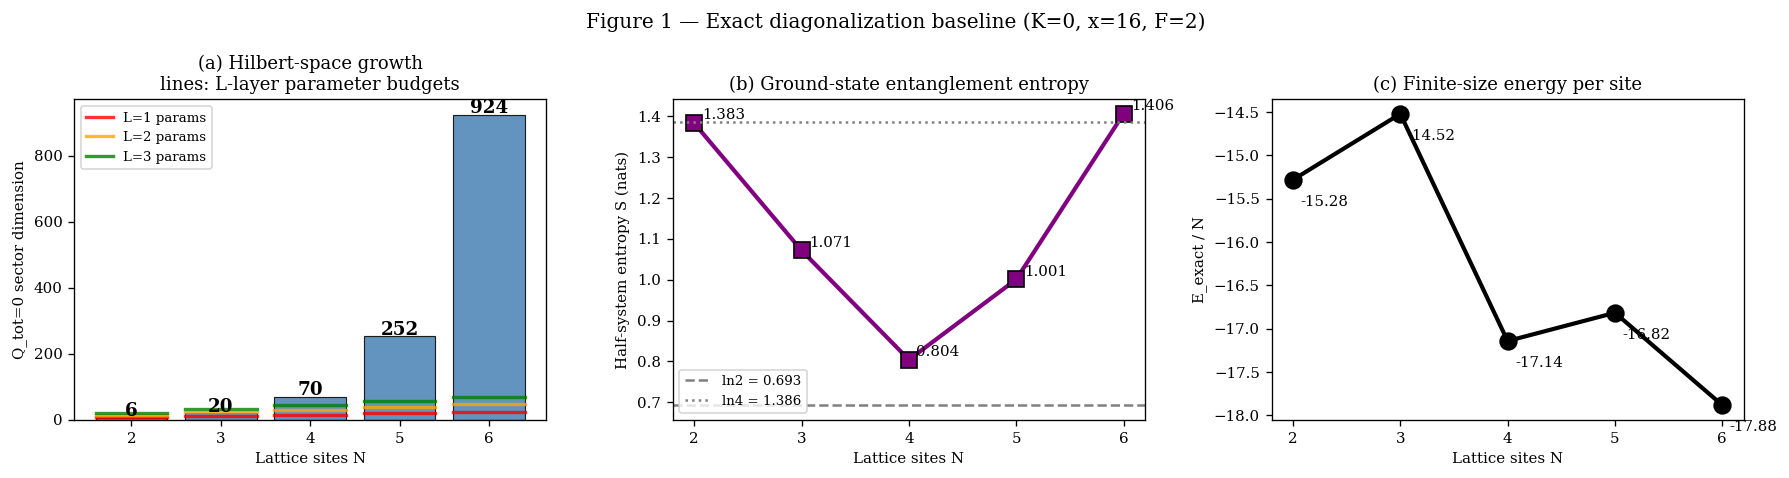

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
N_vals = list(exact_data.keys())
Q0_dims = [exact_data[N]['Q0'] for N in N_vals]
S_vals = [exact_data[N]['S_half'] for N in N_vals]
EpN = [exact_data[N]['E_exact'] / N for N in N_vals]

ax = axes[0]
ax.bar(N_vals, Q0_dims, color='steelblue', edgecolor='k', lw=0.7, alpha=0.85)
for N, d in zip(N_vals, Q0_dims):
    ax.text(N, d + 5, str(d), ha='center', fontsize=11, fontweight='bold')
for L, col in [(1, 'red'), (2, 'orange'), (3, 'green')]:
    for iN, N in enumerate(N_vals):
        nq = N * 2; p = L * (nq - 1 + nq)
        ax.plot([N - 0.4, N + 0.4], [p, p], '-', color=col, lw=2, alpha=0.8,
                label=f'L={L} params' if iN == 0 else '')
ax.set_xlabel('Lattice sites N'); ax.set_ylabel('Q_tot=0 sector dimension')
ax.set_title('(a) Hilbert-space growth\nlines: L-layer parameter budgets')
ax.legend(fontsize=8, loc='upper left'); ax.set_xticks(N_vals)

ax = axes[1]
ax.plot(N_vals, S_vals, 'purple', marker='s', lw=2.5, ms=10, markeredgecolor='k')
for N, S in zip(N_vals, S_vals):
    ax.text(N + 0.07, S + 0.01, f'{S:.3f}', fontsize=9)
ax.axhline(np.log(2), color='gray', ls='--', lw=1.5, label='ln2 = 0.693')
ax.axhline(np.log(4), color='gray', ls=':', lw=1.5, label='ln4 = 1.386')
ax.set_xlabel('Lattice sites N'); ax.set_ylabel('Half-system entropy S (nats)')
ax.set_title('(b) Ground-state entanglement entropy'); ax.legend(fontsize=8); ax.set_xticks(N_vals)

ax = axes[2]
ax.plot(N_vals, EpN, 'ko-', lw=2.5, ms=10, markeredgecolor='k')
for N, E in zip(N_vals, EpN):
    ax.text(N + 0.07, E - 0.3, f'{E:.2f}', fontsize=9)
ax.set_xlabel('Lattice sites N'); ax.set_ylabel('E_exact / N')
ax.set_title('(c) Finite-size energy per site'); ax.set_xticks(N_vals)
plt.suptitle('Figure 1 — Exact diagonalization baseline (K=0, x=16, F=2)', fontsize=12)
plt.tight_layout(); plt.savefig('final_figs/fig1_baseline.png'); plt.show()

### Figure 2 — Expressibility: the p/d error collapse and hardware cost

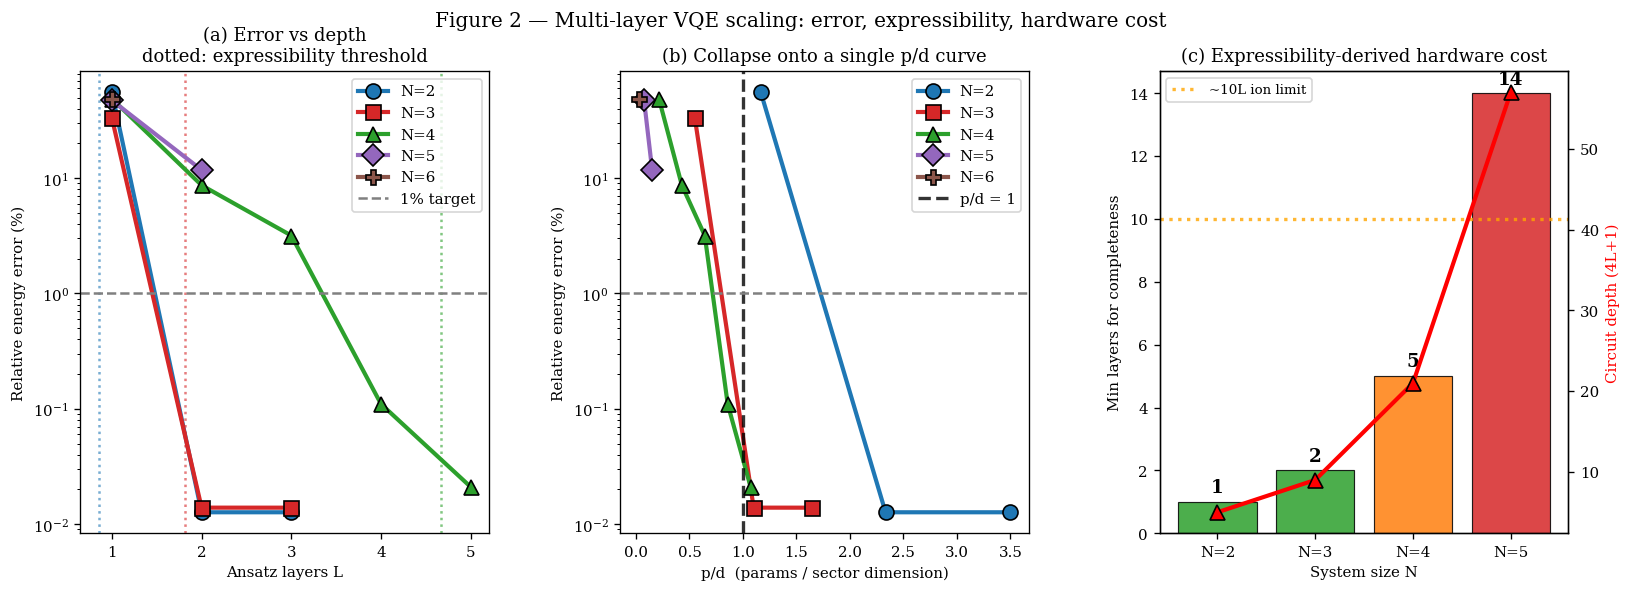

In [17]:
all_data = {}
for N in (2, 3):
    nq = N * 2; n_per = (nq - 1) + nq
    rows = []
    for L in (1, 2, 3):
        E = run_vqe_scaling(N, L, n_restarts=R['scaling'], maxiter=max(R['maxiter'], 1500))
        rows.append((L, L * n_per, E, abs(E - exact_data[N]['E_exact']) / abs(exact_data[N]['E_exact']) * 100))
    all_data[N] = dict(E_exact=exact_data[N]['E_exact'], Q0=exact_data[N]['Q0'],
                       S_half=exact_data[N]['S_half'], nq=nq, layers=rows)
for N in (4, 5, 6):
    all_data[N] = precomputed[N]

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
colors = {2: '#1f77b4', 3: '#d62728', 4: '#2ca02c', 5: '#9467bd', 6: '#8c564b'}
markers = {2: 'o', 3: 's', 4: '^', 5: 'D', 6: 'P'}
for N, d in all_data.items():
    nq = d['nq']; n_per = (nq - 1) + nq
    Lv = [t[0] for t in d['layers']]
    ev = [max(t[3], 5e-3) for t in d['layers']]
    pv = [t[1] for t in d['layers']]
    ax1.semilogy(Lv, ev, color=colors[N], marker=markers[N], lw=2.5, ms=9,
                 markeredgecolor='k', label=f'N={N}')
    Lth = d['Q0'] / n_per
    if Lth <= max(Lv) + 1:
        ax1.axvline(Lth, color=colors[N], ls=':', lw=1.5, alpha=0.6)
    ax2.semilogy([p / d['Q0'] for p in pv], ev, color=colors[N], marker=markers[N],
                 lw=2.5, ms=9, markeredgecolor='k', label=f'N={N}')
ax1.axhline(1.0, color='gray', ls='--', lw=1.5, label='1% target')
ax1.set_xlabel('Ansatz layers L'); ax1.set_ylabel('Relative energy error (%)')
ax1.set_title('(a) Error vs depth\ndotted: expressibility threshold'); ax1.legend(fontsize=9)
ax1.set_xticks([1, 2, 3, 4, 5])
ax2.axvline(1.0, color='k', ls='--', lw=2, alpha=0.8, label='p/d = 1')
ax2.axhline(1.0, color='gray', ls='--', lw=1.5)
ax2.set_xlabel('p/d  (params / sector dimension)'); ax2.set_ylabel('Relative energy error (%)')
ax2.set_title('(b) Collapse onto a single p/d curve'); ax2.legend(fontsize=9)
N_c = [2, 3, 4, 5]
Lmin = [math.ceil(comb(N * 2, N) / ((N * 2 - 1) + N * 2)) for N in N_c]
depth = [4 * L + 1 for L in Lmin]
bar_col = ['#2ca02c' if L <= 3 else '#ff7f0e' if L <= 10 else '#d62728' for L in Lmin]
xp = np.arange(len(N_c)); ax3b = ax3.twinx()
ax3.bar(xp, Lmin, color=bar_col, edgecolor='k', lw=0.7, alpha=0.85)
ax3b.plot(xp, depth, 'r^-', ms=9, lw=2.5, markeredgecolor='k')
for xi, L in enumerate(Lmin):
    ax3.text(xi, L + 0.3, str(L), ha='center', fontsize=11, fontweight='bold')
ax3.set_xticks(xp); ax3.set_xticklabels([f'N={N}' for N in N_c])
ax3.set_xlabel('System size N'); ax3.set_ylabel('Min layers for completeness', color='k')
ax3b.set_ylabel('Circuit depth (4L+1)', color='red')
ax3.set_title('(c) Expressibility-derived hardware cost')
ax3.axhline(10, color='orange', ls=':', lw=2, alpha=0.8, label='~10L ion limit')
ax3.legend(fontsize=8, loc='upper left')
plt.suptitle('Figure 2 — Multi-layer VQE scaling: error, expressibility, hardware cost', fontsize=12)
plt.savefig('final_figs/fig2_expressibility.png'); plt.show()

### Figure 3 — Gauge-invariant vs hardware-efficient over a chemical-potential sweep

Running K-sweep (N=2, L=2, 33 points)...
  done in 600s


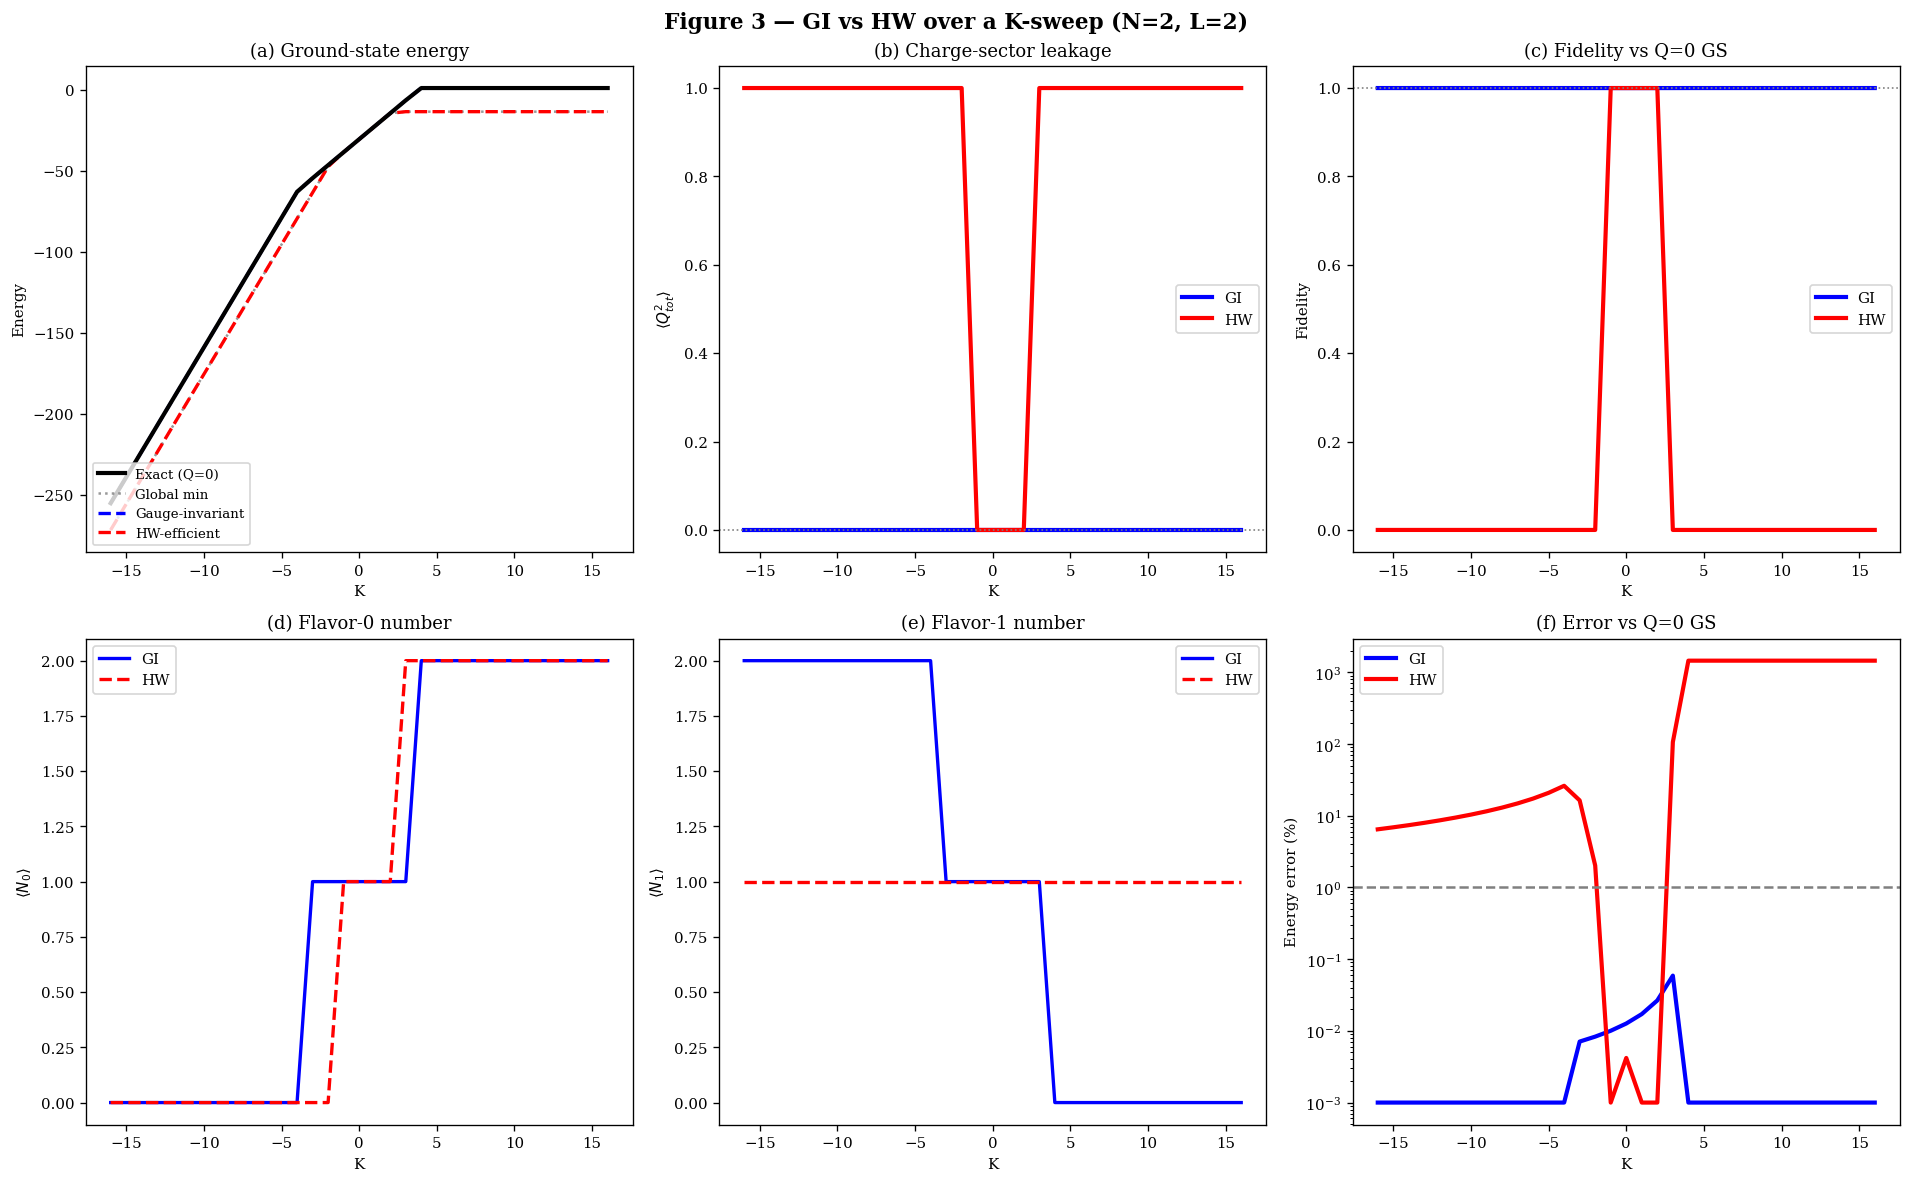

In [18]:
N, F, nq, L = 2, 2, 4, 2
psi0 = make_psi0(N, F)
K_vals = np.linspace(-16, 16, 33)
sweep = {k: [] for k in ['E_q0', 'E_glob', 'E_gi', 'E_hw', 'qt2_gi', 'qt2_hw',
                         'n0_gi', 'n0_hw', 'n1_gi', 'n1_hw', 'fid_gi', 'fid_hw']}
print("Running K-sweep (N=2, L=2, 33 points)...")
t0 = time.time()
for ik, K in enumerate(K_vals):
    H = build_H_full(X, float(K), N, F)
    Q_tot, Q2, N0_op, N1_op = build_operators(N, F)
    bs = [s for s in range(2 ** nq) if bin(s).count("1") == nq // 2]
    w, v = eigh(H[np.ix_(bs, bs)]); E_q0 = float(w[0])
    psi_q0 = np.zeros(2 ** nq, dtype=complex)
    for i, s in enumerate(bs):
        psi_q0[s] = v[i, 0]
    E_glob = float(np.real(np.linalg.eigvalsh(H)[0]))
    Ev_gi, psi_gi = run_vqe(gauge_invariant_ansatz, H, nq, L, L * ((nq - 1) + nq), psi0, n_restarts=R['ksweep'])
    Ev_hw, psi_hw = run_vqe(hw_efficient_ansatz, H, nq, L, L * 2 * nq, psi0, n_restarts=R['ksweep'])
    og = measure_state(psi_gi, Q_tot, Q2, N0_op, N1_op, psi_q0)
    oh = measure_state(psi_hw, Q_tot, Q2, N0_op, N1_op, psi_q0)
    sweep['E_q0'].append(E_q0); sweep['E_glob'].append(E_glob)
    sweep['E_gi'].append(Ev_gi); sweep['E_hw'].append(Ev_hw)
    sweep['qt2_gi'].append(og['Q_tot2']); sweep['qt2_hw'].append(oh['Q_tot2'])
    sweep['n0_gi'].append(og['N0']); sweep['n0_hw'].append(oh['N0'])
    sweep['n1_gi'].append(og['N1']); sweep['n1_hw'].append(oh['N1'])
    sweep['fid_gi'].append(og['fidelity']); sweep['fid_hw'].append(oh['fidelity'])
print(f"  done in {time.time() - t0:.0f}s")
fig, axes = plt.subplots(2, 3, figsize=(16, 10)); K = K_vals
ax = axes[0, 0]
ax.plot(K, sweep['E_q0'], 'k-', lw=2.5, label='Exact (Q=0)', zorder=3)
ax.plot(K, sweep['E_glob'], 'k:', lw=1.5, alpha=0.4, label='Global min')
ax.plot(K, sweep['E_gi'], 'b--', lw=2, label='Gauge-invariant')
ax.plot(K, sweep['E_hw'], 'r--', lw=2, label='HW-efficient')
ax.set_xlabel('K'); ax.set_ylabel('Energy'); ax.set_title('(a) Ground-state energy'); ax.legend(fontsize=8, loc='lower left')
ax = axes[0, 1]
ax.plot(K, sweep['qt2_gi'], 'b-', lw=2.5, label='GI'); ax.plot(K, sweep['qt2_hw'], 'r-', lw=2.5, label='HW')
ax.axhline(0, color='gray', ls=':', lw=1); ax.set_xlabel('K'); ax.set_ylabel(r'$\langle Q_{tot}^2\rangle$')
ax.set_title('(b) Charge-sector leakage'); ax.legend()
ax = axes[0, 2]
ax.plot(K, sweep['fid_gi'], 'b-', lw=2.5, label='GI'); ax.plot(K, sweep['fid_hw'], 'r-', lw=2.5, label='HW')
ax.axhline(1.0, color='gray', ls=':', lw=1); ax.set_xlabel('K'); ax.set_ylabel('Fidelity')
ax.set_title('(c) Fidelity vs Q=0 GS'); ax.legend()
ax = axes[1, 0]
ax.plot(K, sweep['n0_gi'], 'b-', lw=2, label='GI'); ax.plot(K, sweep['n0_hw'], 'r--', lw=2, label='HW')
ax.set_xlabel('K'); ax.set_ylabel(r'$\langle N_0\rangle$'); ax.set_title('(d) Flavor-0 number'); ax.legend()
ax = axes[1, 1]
ax.plot(K, sweep['n1_gi'], 'b-', lw=2, label='GI'); ax.plot(K, sweep['n1_hw'], 'r--', lw=2, label='HW')
ax.set_xlabel('K'); ax.set_ylabel(r'$\langle N_1\rangle$'); ax.set_title('(e) Flavor-1 number'); ax.legend()
ax = axes[1, 2]
eg = [abs(e - ex) / abs(ex) * 100 if abs(ex) > 0.1 else abs(e - ex) for e, ex in zip(sweep['E_gi'], sweep['E_q0'])]
eh = [abs(e - ex) / abs(ex) * 100 if abs(ex) > 0.1 else abs(e - ex) for e, ex in zip(sweep['E_hw'], sweep['E_q0'])]
ax.semilogy(K, [max(e, 1e-3) for e in eg], 'b-', lw=2.5, label='GI')
ax.semilogy(K, [max(e, 1e-3) for e in eh], 'r-', lw=2.5, label='HW')
ax.axhline(1.0, color='gray', ls='--', lw=1.5); ax.set_xlabel('K'); ax.set_ylabel('Energy error (%)')
ax.set_title('(f) Error vs Q=0 GS'); ax.legend()
plt.suptitle('Figure 3 — GI vs HW over a K-sweep (N=2, L=2)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('final_figs/fig3_ksweep.png'); plt.show()

### Figure 4 — Penalty-term threshold for suppressing charge-sector leakage

Penalty sweep at K=-14: physical GS -223.000, global -239.508


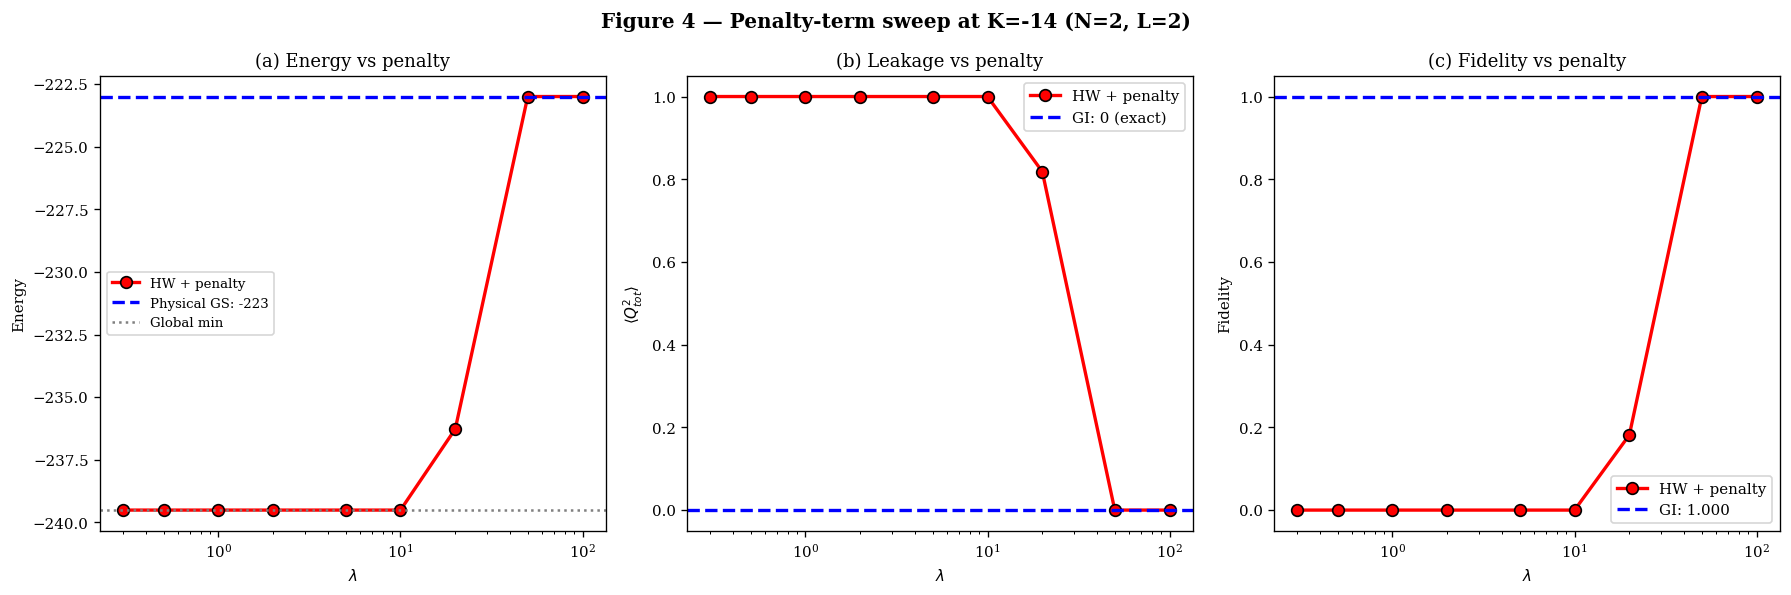

In [20]:
N, F, nq = 2, 2, 4
H_k14 = build_H_full(X, -14.0, N, F)
Q_tot, Q2, N0_op, N1_op = build_operators(N, F)
bs = [s for s in range(2 ** nq) if bin(s).count("1") == nq // 2]
wv, vv = eigh(H_k14[np.ix_(bs, bs)]); E_q0_k14 = float(wv[0])
psi_q0_k14 = np.zeros(2 ** nq, dtype=complex)
for i, s in enumerate(bs):
    psi_q0_k14[s] = vv[i, 0]
psi0 = make_psi0(N, F)
print(f"Penalty sweep at K=-14: physical GS {E_q0_k14:.3f}, global {float(np.real(np.linalg.eigvalsh(H_k14)[0])):.3f}")
lambda_vals = [0, 0.5, 1, 2, 5, 10, 20, 50, 100]
pen = []
for lam in lambda_vals:
    E, psi = run_vqe(hw_efficient_ansatz, H_k14, nq, 2, 16, psi0,
                     n_restarts=R['penalty'], penalty_op=Q2, penalty_lam=lam)
    o = measure_state(psi, Q_tot, Q2, N0_op, N1_op, psi_q0_k14)
    pen.append(dict(lam=lam, E=E, **o))
E_gi_ref, psi_gi_ref = run_vqe(gauge_invariant_ansatz, H_k14, nq, 2, 14, psi0, n_restarts=R['penalty'])
o_gi = measure_state(psi_gi_ref, Q_tot, Q2, N0_op, N1_op, psi_q0_k14)
fig, axes = plt.subplots(1, 3, figsize=(15, 5)); lp = [max(l, 0.3) for l in lambda_vals]
ax = axes[0]
ax.semilogx(lp, [r['E'] for r in pen], 'r-o', lw=2, ms=7, markeredgecolor='k', label='HW + penalty')
ax.axhline(E_q0_k14, color='blue', ls='--', lw=2, label=f'Physical GS: {E_q0_k14:.0f}')
ax.axhline(float(np.real(np.linalg.eigvalsh(H_k14)[0])), color='gray', ls=':', lw=1.5, label='Global min')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel('Energy'); ax.set_title('(a) Energy vs penalty'); ax.legend(fontsize=8)
ax = axes[1]
ax.semilogx(lp, [r['Q_tot2'] for r in pen], 'r-o', lw=2, ms=7, markeredgecolor='k', label='HW + penalty')
ax.axhline(0, color='blue', ls='--', lw=2, label='GI: 0 (exact)')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel(r'$\langle Q_{tot}^2\rangle$'); ax.set_title('(b) Leakage vs penalty'); ax.legend(fontsize=9)
ax = axes[2]
ax.semilogx(lp, [r['fidelity'] for r in pen], 'r-o', lw=2, ms=7, markeredgecolor='k', label='HW + penalty')
ax.axhline(o_gi['fidelity'], color='blue', ls='--', lw=2, label=f'GI: {o_gi["fidelity"]:.3f}')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel('Fidelity'); ax.set_title('(c) Fidelity vs penalty'); ax.legend(fontsize=9)
plt.suptitle('Figure 4 — Penalty-term sweep at K=-14 (N=2, L=2)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('final_figs/fig4_penalty.png'); plt.show()

### Figure 5 — Optimization stability over 20 random restarts

Stability: 20 restarts at K=0, N=2, L=2


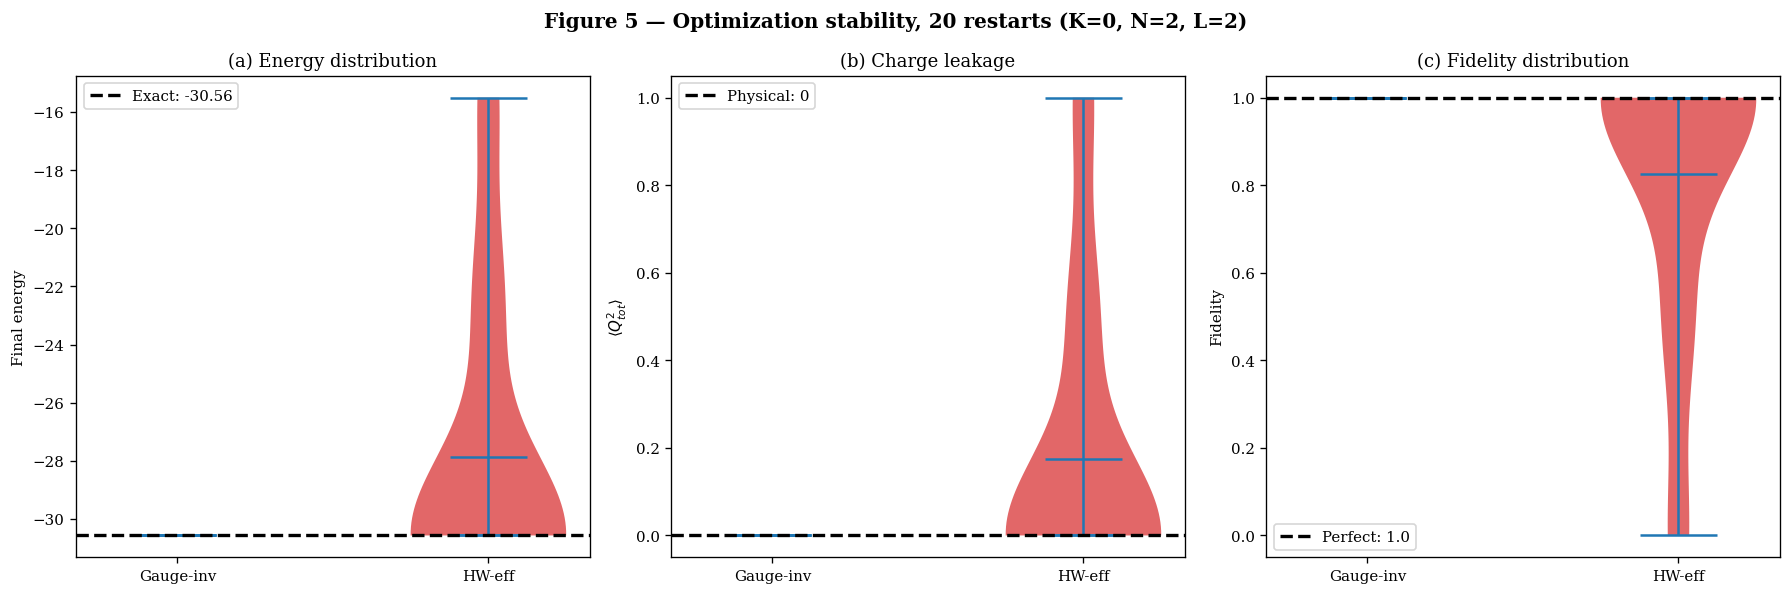

In [21]:
N, F, nq = 2, 2, 4
H0 = build_H_full(X, 0.0, N, F)
Q_tot, Q2, N0_op, N1_op = build_operators(N, F)
bs = [s for s in range(2 ** nq) if bin(s).count("1") == nq // 2]
w0, v0 = eigh(H0[np.ix_(bs, bs)]); E_q0_0 = float(w0[0])
psi_q0_0 = np.zeros(2 ** nq, dtype=complex)
for i, s in enumerate(bs):
    psi_q0_0[s] = v0[i, 0]
psi0 = make_psi0(N, F)
print(f"Stability: {R['stability']} restarts at K=0, N=2, L=2")
stability_data = {}
for name, fn, nper in [("GI", gauge_invariant_ansatz, (nq - 1) + nq), ("HW", hw_efficient_ansatz, 2 * nq)]:
    rng = np.random.default_rng(42); obs_list = []
    for _ in range(R['stability']):
        t0 = rng.uniform(-np.pi, np.pi, 2 * nper)
        r = minimize(lambda th: float(np.real(fn(th, psi0, nq, 2).conj() @ H0 @ fn(th, psi0, nq, 2))),
                     t0, method='COBYLA', options={'maxiter': R['maxiter'], 'rhobeg': 0.5})
        psi_f = fn(r.x, psi0, nq, 2)
        o = measure_state(psi_f, Q_tot, Q2, N0_op, N1_op, psi_q0_0)
        o['E'] = float(np.real(psi_f.conj() @ H0 @ psi_f)); obs_list.append(o)
    stability_data[name] = obs_list
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, ylabel, title in [
        (axes[0], 'E', 'Final energy', '(a) Energy distribution'),
        (axes[1], 'Q_tot2', r'$\langle Q_{tot}^2\rangle$', '(b) Charge leakage'),
        (axes[2], 'fidelity', 'Fidelity', '(c) Fidelity distribution')]:
    gv = [o[metric] for o in stability_data['GI']]; hv = [o[metric] for o in stability_data['HW']]
    vp = ax.violinplot([gv, hv], positions=[1, 2], showmeans=True, showmedians=True)
    vp['bodies'][0].set_facecolor('#1f77b4'); vp['bodies'][0].set_alpha(0.7)
    vp['bodies'][1].set_facecolor('#d62728'); vp['bodies'][1].set_alpha(0.7)
    if metric == 'E':
        ax.axhline(E_q0_0, color='k', ls='--', lw=2, label=f'Exact: {E_q0_0:.2f}')
    elif metric == 'Q_tot2':
        ax.axhline(0, color='k', ls='--', lw=2, label='Physical: 0')
    else:
        ax.axhline(1.0, color='k', ls='--', lw=2, label='Perfect: 1.0')
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Gauge-inv', 'HW-eff'])
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle(f'Figure 5 — Optimization stability, {R["stability"]} restarts (K=0, N=2, L=2)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('final_figs/fig5_stability.png'); plt.show()

### Figure 6 — Convergence traces, single-layer vs two-layer

Computing convergence traces (K=0, N=2, L=2)...


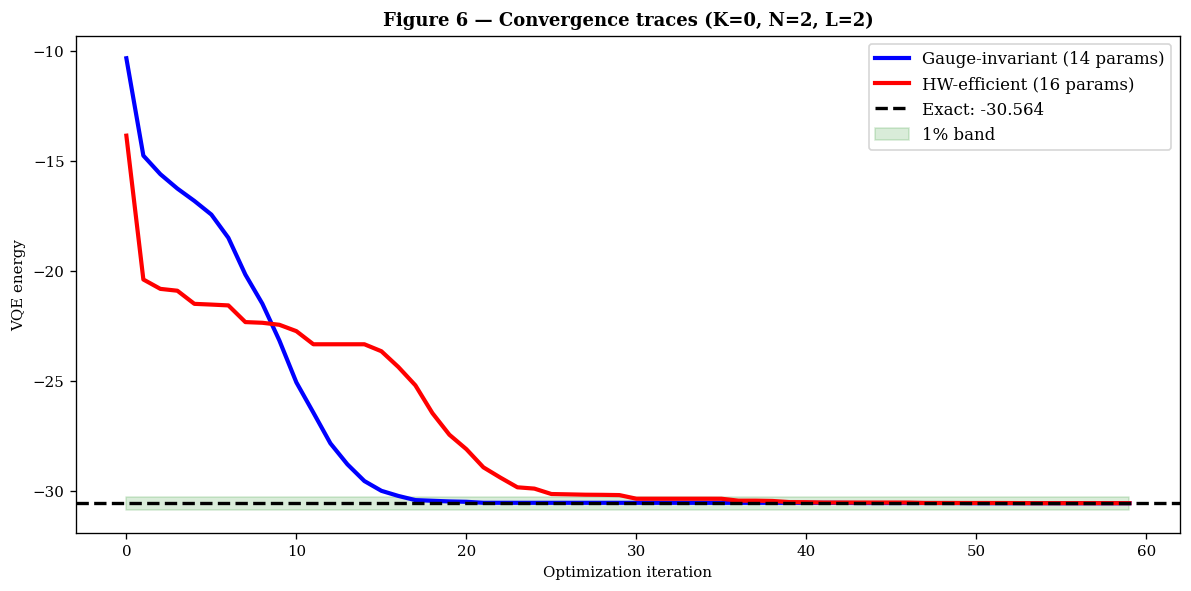

In [22]:
def conv_trace(fn, H, nq, L, n_params, psi0, n_steps=60, n_tries=5, seed=7):
    rng = np.random.default_rng(seed); best, best_final = None, np.inf
    for _ in range(n_tries):
        theta = rng.uniform(-np.pi, np.pi, n_params); trace = []
        for step in range(n_steps):
            rho = max(0.5 * (0.95 ** step), 0.03)
            r = minimize(lambda th: float(np.real(fn(th, psi0, nq, L).conj() @ H @ fn(th, psi0, nq, L))),
                         theta, method='COBYLA', options={'maxiter': max(n_params + 2, 12), 'rhobeg': rho})
            theta = r.x
            trace.append(float(np.real(fn(theta, psi0, nq, L).conj() @ H @ fn(theta, psi0, nq, L))))
        if trace[-1] < best_final:
            best_final, best = trace[-1], trace
    return best
N, nq = 2, 4
H0 = build_H_full(X, 0.0); psi0 = make_psi0(2)
bs = [s for s in range(16) if bin(s).count("1") == 2]
E_q0_0 = float(eigh(H0[np.ix_(bs, bs)], eigvals_only=True)[0])
print("Computing convergence traces (K=0, N=2, L=2)...")
tr_gi = conv_trace(gauge_invariant_ansatz, H0, nq, 2, 14, psi0, n_tries=R['conv'])
tr_hw = conv_trace(hw_efficient_ansatz, H0, nq, 2, 16, psi0, n_tries=R['conv'])
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(tr_gi)), tr_gi, 'b-', lw=2.5, label='Gauge-invariant (14 params)')
ax.plot(range(len(tr_hw)), tr_hw, 'r-', lw=2.5, label='HW-efficient (16 params)')
ax.axhline(E_q0_0, color='k', ls='--', lw=2, label=f'Exact: {E_q0_0:.3f}')
band = abs(E_q0_0) * 0.01
ax.fill_between(range(len(tr_gi)), E_q0_0 - band, E_q0_0 + band, alpha=0.15, color='green', label='1% band')
ax.set_xlabel('Optimization iteration'); ax.set_ylabel('VQE energy')
ax.set_title('Figure 6 — Convergence traces (K=0, N=2, L=2)', fontweight='bold'); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig('final_figs/fig6_convergence.png'); plt.show()

### Figure 7 — Phase boundary under hardware noise + ZNE (nu0only, |K| ~ 5.6)

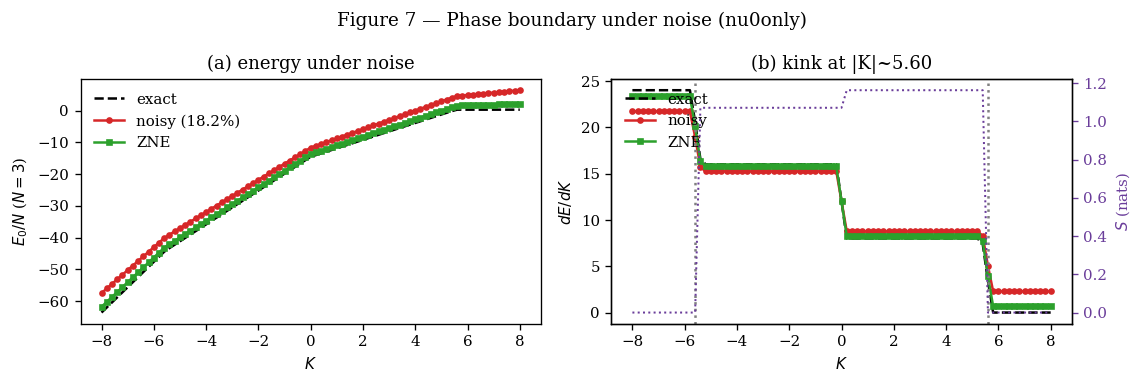

boundary |K|~5.60  S_max=1.163  kink suppression=19.0%


In [23]:
N_noise, NCX, conv = 3, NCX_N3_L2, "nu0only"
def _phase_boundary(p=0.01):
    Kv = np.linspace(-8, 8, 81)
    ex, mx, S = np.array([exact_and_mix(N_noise, k, convention=conv) for k in Kv]).T
    no = noisy(ex, mx, p, NCX); zn = zne_linear(ex, mx, p, NCX)
    kb = boundary_K(N_noise, convention=conv)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2))
    ax[0].plot(Kv, ex / N_noise, 'k--', label='exact')
    ax[0].plot(Kv, no / N_noise, 'o-', color='#d62728', ms=3, label=f'noisy ({100 * (1 - (1 - p) ** NCX):.1f}%)')
    ax[0].plot(Kv, zn / N_noise, 's-', color='#2ca02c', ms=3, label='ZNE')
    ax[0].set_xlabel('$K$'); ax[0].set_ylabel(r'$E_0/N$ ($N=3$)'); ax[0].set_title('(a) energy under noise')
    ax[0].legend(frameon=False)
    de, dn, dz = np.gradient(ex, Kv), np.gradient(no, Kv), np.gradient(zn, Kv)
    ax[1].plot(Kv, de, 'k--', label='exact'); ax[1].plot(Kv, dn, 'o-', color='#d62728', ms=3, label='noisy')
    ax[1].plot(Kv, dz, 's-', color='#2ca02c', ms=3, label='ZNE')
    ax[1].axvline(kb, color='gray', ls=':'); ax[1].axvline(-kb, color='gray', ls=':')
    ax[1].set_xlabel('$K$'); ax[1].set_ylabel('$dE/dK$'); ax[1].set_title(f'(b) kink at |K|~{kb:.2f}')
    a2 = ax[1].twinx(); a2.plot(Kv, S, ':', color='#6a3d9a', lw=1.2)
    a2.set_ylabel('$S$ (nats)', color='#6a3d9a'); a2.tick_params(axis='y', colors='#6a3d9a')
    ax[1].legend(frameon=False, loc='upper left')
    plt.suptitle('Figure 7 — Phase boundary under noise (nu0only)', fontsize=11)
    plt.tight_layout(); plt.savefig('final_figs/fig7_phase_boundary.png'); plt.show()
    w_eff = (1 - p) ** NCX * (1 - 2 * SPAM_DEFAULT)
    return kb, float(S.max()), 100 * (1 - w_eff)
kb, smax, sup = _phase_boundary()
print(f"boundary |K|~{kb:.2f}  S_max={smax:.3f}  kink suppression={sup:.1f}%")

### Figure 8 — ZNE robustness vs per-gate depolarizing rate (nu0only)

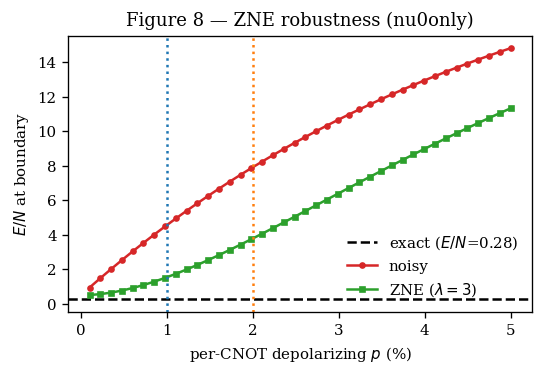

ZNE residual (energy units): p=1% -> 3.80, p=2% -> 10.53, p=5% -> 33.14


In [24]:
kb = boundary_K(N_noise, convention=conv)
E0, Emix, _ = exact_and_mix(N_noise, kb - 0.05, convention=conv)
ps = np.linspace(0.001, 0.05, 40)
no = np.array([noisy(E0, Emix, p, NCX) for p in ps])
zn = np.array([zne_linear(E0, Emix, p, NCX) for p in ps])
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.axhline(E0 / N_noise, color='k', ls='--', label=f'exact ($E/N$={E0/N_noise:.2f})')
ax.plot(ps * 100, no / N_noise, 'o-', color='#d62728', ms=3, label='noisy')
ax.plot(ps * 100, zn / N_noise, 's-', color='#2ca02c', ms=3, label=r'ZNE ($\lambda=3$)')
ax.axvline(1.0, color='#1f77b4', ls=':'); ax.axvline(2.0, color='#ff7f0e', ls=':')
ax.set_xlabel('per-CNOT depolarizing $p$ (%)'); ax.set_ylabel(r'$E/N$ at boundary')
ax.set_title('Figure 8 — ZNE robustness (nu0only)'); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig('final_figs/fig8_zne_robustness.png'); plt.show()
res = {p: abs(zne_linear(E0, Emix, p, NCX) - E0) for p in (0.01, 0.02, 0.05)}
print(f"ZNE residual (energy units): p=1% -> {res[0.01]:.2f}, p=2% -> {res[0.02]:.2f}, p=5% -> {res[0.05]:.2f}")

---
**Done.** All figures are in `final_figs/`. For the manuscript, rename
`final_figs/fig7_phase_boundary.png` and `final_figs/fig8_zne_robustness.png` to
`phase_boundary_final.png` and `robustness_limit_final.png`. The exact baseline in
Fig 8 sits at E/N ~ +0.28 in `nu0only` (the old antisym panel showed -21.86); the
ZNE residual numbers (3.8 / 10.5 / 33 at p = 1/2/5%) are convention-correct.